<a href="https://colab.research.google.com/github/Ashishk811/MLUP-class/blob/main/kNN_Iris_Dataset/kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Ashishk811/MLUP-class.git

Cloning into 'MLUP-class'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (104/104), done.
remote: Total 106 (delta 34), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 411.87 KiB | 6.54 MiB/s, done.
Resolving deltas: 100% (34/34), done.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
file_path = r"/content/MLUP-class/kNN_Iris_Dataset/Iris.csv"

In [4]:
def load_iris(file_path):
    try:
        df = pd.read_csv(
            file_path,
            na_values='?',
        )

        print("\nDataset loaded successfully!")
        print(f"Shape: {df.shape}")
        print("\nFirst 5 rows:")
        print(df.head())

        missing_count = df.isnull().sum()
        if missing_count.any():
            print("\nMissing values detected:")
            print(missing_count[missing_count > 0])
        else:
            print("\nNo missing values found.")

        return df

    except Exception as e:
        print("Error loading dataset:", e)
        return None

df = load_iris(file_path)


Dataset loaded successfully!
Shape: (150, 6)

First 5 rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

No missing values found.


## 1st method pre-processing

In [5]:
df = df.drop('Id', axis=1)
print("DataFrame after deleting the 'Id' column:")
print(df.shape)
display(df.head())

DataFrame after deleting the 'Id' column:
(150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
print("Varieties of class levels in 'Species' column and their counts:")
display(df['Species'].value_counts())

Varieties of class levels in 'Species' column and their counts:


,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


## 1st method Algorithm

In [7]:
from sklearn.model_selection import train_test_split
from collections import Counter

In [8]:
# Features and target
X = df.iloc[:, 0:4].values   # SepalLength, SepalWidth, PetalLength, PetalWidth
y = df.iloc[:, 4].values     # Species

In [9]:
# Convert species names to numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [11]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

In [12]:
# KNN function
def knn_predict(X_train, y_train, X_test, k=3):
    predictions = []

    for test_point in X_test:
        distances = []

        for i in range(len(X_train)):
            distance = euclidean_distance(test_point, X_train[i])
            distances.append((distance, y_train[i]))

        # Sort distances
        distances.sort(key=lambda x: x[0])

        # Get k nearest neighbors
        k_nearest = distances[:k]

        # Majority voting
        labels = [label for _, label in k_nearest]
        most_common = Counter(labels).most_common(1)
        predictions.append(most_common[0][0])

    return np.array(predictions)

In [13]:
# Predict
y_pred = knn_predict(X_train, y_train, X_test, k=3)

In [14]:
# Accuracy
accuracy = np.sum(y_pred == y_test) / len(y_test)
print("Accuracy:", accuracy)

Accuracy: 1.0


## 2nd Method

In [15]:
from sklearn import datasets
import seaborn as sns

In [16]:
iris=datasets.load_iris()
iris_df= pd.DataFrame(iris.data,columns= iris.feature_names)
iris_df['target']=iris.target
print(pd.concat([iris_df.head(3),iris_df.tail(3)]))

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     target  
0         0  
1         0  
2         0  
147       2  
148       2  
149       2  


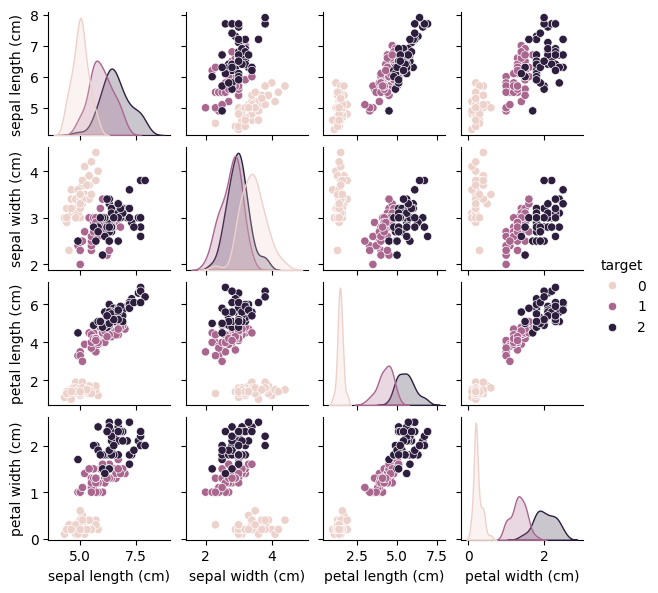

targets:['setosa' 'versicolor' 'virginica']
setosa


In [17]:
sns.pairplot(iris_df,hue='target',height=1.5)
plt.show()
print('targets:{}'.format(iris.target_names),iris.target_names[0],sep="\n")

In [22]:
import sklearn.model_selection as skms

X_train, X_test, y_train, y_test = skms.train_test_split(
    iris.data,iris.target,test_size=0.2)

print("Train features: ", X_train.shape)
print("Train labels: ", y_train.shape)
print("Test features shape: ", X_test.shape)

# 0.2 means 20 % test data
# iris.data are the inputs(features) and iris.target is for predicting value(levels)

Train features:  (120, 4)
Train labels:  (120,)
Test features shape:  (30, 4)


In [23]:
from sklearn import neighbors, metrics

knn= neighbors.KNeighborsClassifier(n_neighbors=3)
fit= knn.fit(X_train,y_train)
preds= fit.predict(X_test)
print("3NN accuracy: ", metrics.accuracy_score(y_test,preds))

3NN accuracy:  1.0


In [24]:
from sklearn import naive_bayes
nb= naive_bayes.GaussianNB()

In [25]:
fit=nb.fit(X_train,y_train)
preds=fit.predict(X_test)
print("NB accuracy:",metrics.accuracy_score(y_test,preds))

NB accuracy: 0.9666666666666667
